# Topological Data Analysis for Surficial Geology Classification: A Comparative Study with Traditional Geomorphology and Pre-trained Deep Learning Features

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pickle

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

## Introduction

### Research Question

Can Topological Data Analysis (TDA) features serve as a computationally efficient and predictively powerful alternative to traditional geomorphology metrics for classifying surficial geology from Digital Elevation Models (DEMs)? How do these compact, mathematically-derived topological features (e.g., Persistence Images) compare, in terms of predictive power and semantic alignment, to the high-dimensional features extracted from frozen pre-trained computer vision models (transfer learning baselines)?

### Context and Importance

Surficial geology classification from DEMs is a fundamental task in geomorphology and environmental science. Traditional geomorphological features (slope, aspect, curvature, etc.) are interpretable but computationally expensive and may miss critical topological structures. Pre-trained deep learning models (frozen feature extractors) offer high-dimensional feature representations but are less interpretable and, in the case of ResNet-50, did not achieve statistical equivalence to traditional baselines. ViT-Base (Geometry) did achieve statistical equivalence (F1 = 0.647), but with higher computational cost and lower interpretability than TDA-traditional hybrids. TDA provides a mathematically rigorous framework to extract topological features that capture the shape and connectivity of terrain, potentially offering a middle ground: interpretable, efficient, and robust.

### Overall Approach

We compare three categories of feature extraction methods:
1. **Traditional Methods**: Geomorphological derivatives (slope, aspect, curvature, TPI, TWI, TRI), texture features (GLCM), and landform classifications (geomorphons)
2. **TDA Methods**: Betti curves, Persistence Landscapes, and Persistence Images computed on elevation, slope, and superlevel filtrations
3. **Transfer Learning Baselines**: Frozen pre-trained vision models (ResNet-50, ViT-Base) applied to geometry and RGB inputs, with extracted features fed into Random Forest classifiers (end-to-end fine-tuning was not evaluated)

All methods are evaluated using Random Forest classification with spatial cross-validation to assess generalization to unseen terrain. We use statistical equivalence testing (TOST) and semantic alignment analysis to compare approaches comprehensively.

## Data

### Dataset Description

We use an existing, AI-ready DEM dataset covering **Warren and Hardin Counties, Kentucky**, an ideal region for this study due to its topologically complex karst terrain, including Mammoth Cave National Park. The dataset consists of:

- **Input Data**: Digital Elevation Model (DEM) tiles in raster image format
- **Output Data**: Multi-label classification indicating the presence/absence of seven surficial geologic deposit types:
  - Qal: Alluvium
  - Qr: Residuum
  - Qls: Landslide deposits
  - Qc: Colluvium
  - Qe: Eolian deposits
  - Qp: Peat
  - Qm: Marine deposits

### Data Preprocessing

- DEM tiles were standardized and normalized
- Labels were encoded as binary multi-label vectors
- Tiles were grouped by geological region for spatial cross-validation
- Feature extraction was performed on standardized DEM tiles

### Sample Sizes

The dataset consists of **30,643 DEM tiles** from Warren and Hardin Counties, Kentucky, distributed across eight distinct geological regions. Each tile represents a 256×256 pixel area at 1-meter resolution (256m × 256m ground area). The dataset exhibits significant class imbalance typical of geological mapping: Residuum (Qr) and Marine deposits (Qm) are highly prevalent (59.7% and 95.8% respectively), while Landslide deposits (Qls) are rare (0.6%). Alluvium (Qal), Eolian (Qe), and Peat (Qp) show moderate prevalence (35.8%, 36.8%, and 22.1% respectively), while Colluvium (Qc) is relatively uncommon (4.3%).

**Geographic Distribution:**
- 8 unique geological regions (datasets)
- Spatial grouping enables 5-fold spatial cross-validation (GroupKFold)

**Class Distribution:**
See cell output below for detailed per-class sample counts.

In [2]:
# Load data summary
PROJECT_ROOT = Path("../..").resolve()
data_path = PROJECT_ROOT / "data" / "processed" / "final_project"

# Load metadata and labels
metadata = json.load(open(data_path / 'metadata.json'))
labels_all = np.load(data_path / 'labels.npy')

print(f"Dataset Summary:")
print(f"  Number of samples: {len(labels_all):,}")
print(f"  Number of classes: {labels_all.shape[1]}")
print(f"  Number of datasets: {len(metadata['datasets']['unique_datasets'])}")
print(f"\nGeographic Regions:")
for dataset in metadata['datasets']['unique_datasets']:
    print(f"  - {dataset}")

# Display per-class sample sizes
class_names = ['Qal (Alluvium)', 'Qr (Residuum)', 'Qls (Landslide)', 
               'Qc (Colluvium)', 'Qe (Eolian)', 'Qp (Peat)', 'Qm (Marine)']
print(f"\nPer-Class Sample Sizes:")
print(f"{'Class':<25} {'Samples':>10} {'Percentage':>12}")
print("-" * 50)
for i, name in enumerate(class_names):
    n_samples = labels_all[:, i].sum()
    pct = 100 * n_samples / len(labels_all)
    print(f"{name:<25} {n_samples:>10,} {pct:>11.1f}%")

print("\nNote: Percentages sum to >100% due to multi-label classification (tiles can have multiple geology classes).")

Dataset Summary:
  Number of samples: 30,643
  Number of classes: 7
  Number of datasets: 8

Geographic Regions:
  - earthscape_hardin_howevalley
  - earthscape_hardin_sonora
  - earthscape_warren_bgn
  - earthscape_warren_bgs
  - earthscape_warren_bristow
  - earthscape_warren_hadley
  - earthscape_warren_rockfield
  - earthscape_warren_smithsgrove

Per-Class Sample Sizes:
Class                        Samples   Percentage
--------------------------------------------------
Qal (Alluvium)              10,972.0        35.8%
Qr (Residuum)               18,288.0        59.7%
Qls (Landslide)                194.0         0.6%
Qc (Colluvium)               1,327.0         4.3%
Qe (Eolian)                 11,290.0        36.8%
Qp (Peat)                    6,781.0        22.1%
Qm (Marine)                 29,344.0        95.8%

Note: Percentages sum to >100% due to multi-label classification (tiles can have multiple geology classes).


In [3]:
# Data cleaning and preprocessing summary
print("Data Preprocessing Steps:")
print("1. DEM tiles standardized (mean=0, std=1)")
print("2. Multi-label encoding (binary vectors)")
print("3. Spatial grouping by geological region")
print("4. Feature extraction on standardized tiles")
print("\nNo additional cleaning required - dataset was already preprocessed.")

Data Preprocessing Steps:
1. DEM tiles standardized (mean=0, std=1)
2. Multi-label encoding (binary vectors)
3. Spatial grouping by geological region
4. Feature extraction on standardized tiles

No additional cleaning required - dataset was already preprocessed.


## Methods

### Feature Extraction Methods

#### Traditional Geomorphological Features

1. **Core Derivatives**: Single-scale WhiteboxTools features (Aspect, Tangential curvature, Slope, TPI, TWI, TRI)
2. **Multi-scale Derivatives**: Multi-scale WhiteboxTools features, including all TPI radii
3. **Texture Composite**: GLCM texture features combined with roughness and entropy measures
4. **Geomorphons**: Landform classification histograms

#### Topological Data Analysis (TDA) Features

TDA features were computed using three filtrations:
- **Elevation Filtration**: Direct DEM values
- **Slope Filtration**: Slope raster derived from DEM
- **Superlevel Filtration**: Negated DEM (inverted elevation)

For each filtration, three vectorizations were computed:
- **Betti Curves**: Time series of Betti numbers (β₀, β₁) across filtration values
- **Persistence Landscapes**: Functional summaries of persistence diagrams
- **Persistence Images**: Grid-based representations of persistence diagrams

#### Transfer Learning Baselines (Pre-trained Deep Learning Features)

**Note**: We evaluate frozen pre-trained models (transfer learning) rather than end-to-end fine-tuning. Features are extracted from frozen models and fed into Random Forest classifiers. End-to-end fine-tuning of Transformers (ViT-Base) or large CNNs (ResNet-50) on 30,000+ tiles would require substantial computational resources (GPU training time and hyperparameter tuning). They would shift the focus from feature-extraction comparison to complete model training. Our frozen feature extractor approach is a common practical deployment strategy in which pre-trained models are used as feature extractors, enabling direct comparison with traditional and TDA feature extraction methods. This design choice aligns with our research question's focus on feature-extraction efficiency and predictive power rather than on end-to-end model optimization.

**Arena 1: Geometry Inputs** (Elevation, Slope, TPI as 3-channel images) — referred to as "(Geometry)" in results tables
- ResNet-50 features (frozen pre-trained on ImageNet)
- ViT-Base features (frozen pre-trained on ImageNet)

**Arena 2: RGB Inputs** (Aerial imagery) — referred to as "(RGB)" in results tables
- ResNet-50 features (frozen pre-trained on ImageNet)
- ViT-Base features (frozen pre-trained on ImageNet)

#### Combined Feature Sets

- Multi-scale + Texture
- Multi-scale + TDA (Betti, Landscapes, PersImages)
- Multi-scale + Texture + TDA

### Evaluation Strategy

#### Cross-Validation

**Random K-Fold CV**: Standard 5-fold cross-validation with random splits
- Provides baseline performance estimate
- May suffer from spatial autocorrelation leakage

**Spatial K-Fold CV**: 5-fold GroupKFold (grouped by geological region)
- Groups tiles by geological region (dataset name) into five folds
- Ensures test regions are never seen during training
- Provides an honest estimate of generalization to new terrain
- More conservative but realistic performance assessment

#### Classifier

- **Model**: Random Forest with MultiOutputClassifier wrapper
- **Parameters**: n_estimators=64, max_depth=15, max_features='sqrt', class_weight='balanced'
- **Metric**: F1-macro score (suitable for imbalanced, multi-label classification)

#### Statistical Analysis

**TOST (Two One-Sided Tests) for Equivalence**
- Tests whether |F1_TDA - F1_baseline| < δ
- Equivalence margin: δ = 0.25 × σ_spatial(baseline) = 0.0414, where σ_spatial(baseline) = 0.1658 (baseline spatial CV standard deviation)
- Baseline: multiscale_derivatives (strong traditional baseline)
- Applied to both spatial and random CV results
- Uses paired t-tests on CV fold differences (n=5 folds, df=4)

**Note**: Wilcoxon signed-rank tests were considered but not used due to insufficient statistical power with n=5 folds and 70 comparisons after Bonferroni correction. TOST provides more informative comparisons for this experimental design.

**Cohen's d Effect Size**
- Standardized measure of the magnitude of difference
- Calculated as mean difference/std of differences (paired samples)
- Interpretation: <0.2 (negligible), 0.2-0.5 (small), 0.5-0.8 (medium), >0.8 (large)
- For equivalence testing, the absolute mean difference (not d) determines equivalence

#### Semantic Alignment Analysis

- Extract feature importances from trained Random Forest models
- Map features to interpretable geomorphological concepts
- Visualize what each method category prioritizes
- Compute alignment matrix (correlation of feature importances across methods)

In [4]:
# Load CV results from quick_comparison.ipynb
cv_results_path = data_path / 'cv_results.npy'
cv_results = np.load(cv_results_path, allow_pickle=True).item()

# Extract scores - handle both nested (multi-classifier) and flat (single classifier) formats
cv_scores_random_raw = cv_results.get('scores_random', {})
cv_scores_spatial_raw = cv_results.get('scores_spatial', {})
classifiers_used = cv_results.get('classifiers', ['Random Forest'])

# Check if nested structure (multi-classifier format)
if len(cv_scores_random_raw) > 0:
    first_key = list(cv_scores_random_raw.keys())[0]
    if isinstance(cv_scores_random_raw[first_key], dict):
        # Nested format: cv_scores_random[classifier_name][feature_key] = scores
        available_classifiers = list(cv_scores_random_raw.keys())
        if 'Random Forest' in available_classifiers:
            clf_name = 'Random Forest'
        elif classifiers_used and classifiers_used[0] in available_classifiers:
            clf_name = classifiers_used[0]
        else:
            clf_name = available_classifiers[0]
            print(f"⚠ 'Random Forest' not found. Available classifiers: {available_classifiers}")
            print(f"  Using {clf_name} instead")
        
        cv_scores_random = cv_scores_random_raw.get(clf_name, {})
        cv_scores_spatial = cv_scores_spatial_raw.get(clf_name, {})
        print(f"✓ Multi-classifier results detected, using {clf_name}")
    else:
        # Flat format: cv_scores_random[feature_key] = scores (old format)
        cv_scores_random = cv_scores_random_raw
        cv_scores_spatial = cv_scores_spatial_raw
        print(f"✓ Single-classifier results (legacy format)")
else:
    cv_scores_random = {}
    cv_scores_spatial = {}
    print("⚠ No CV results found")

print(f"  Random CV: {len(cv_scores_random)} methods")
print(f"  Spatial CV: {len(cv_scores_spatial)} methods")
print(f"  Feature dimensions: {len(cv_results.get('shapes', {}))} feature sets")

✓ Single-classifier results (legacy format)
  Random CV: 36 methods
  Spatial CV: 36 methods
  Feature dimensions: 36 feature sets


In [5]:
# Load statistical test results from tost_equivalence_testing.ipynb
df_stats = pd.read_csv(data_path / 'statistical_test_results.csv')
df_stats_bonf = pd.read_csv(data_path / 'statistical_test_bonferroni.csv')
df_stats_summary = pd.read_csv(data_path / 'statistical_test_summary.csv')

print(f"✓ Loaded statistical test results")
print(f"  Primary analysis: {len(df_stats)} methods")
print(f"  Bonferroni analysis: {len(df_stats_bonf)} methods")
print(f"  Summary statistics: {len(df_stats_summary)} methods")

# Load timing data
timing = np.load(data_path / 'timing.npy', allow_pickle=True).item()
print(f"  Timing data: {len(timing)} feature extraction methods")

# Load feature importance results
try:
    with open(data_path / 'feature_importance_results.pkl', 'rb') as f:
        feature_importance = pickle.load(f)
    df_importance = pd.read_csv(data_path / 'feature_importance_summary.csv')
    print(f"  Feature importance: {len(df_importance)} methods analyzed")
except Exception as e:
    print(f"  Feature importance: Not available ({e})")
    feature_importance = None
    df_importance = None

✓ Loaded statistical test results
  Primary analysis: 35 methods
  Bonferroni analysis: 35 methods
  Summary statistics: 35 methods
  Timing data: 25 feature extraction methods
  Feature importance: 36 methods analyzed


## Results

### Performance Comparison

The performance comparison table below shows F1-macro scores for all methods evaluated using both random and spatial cross-validation. Methods are sorted by spatial CV performance (most realistic estimate). As shown in Figure 1, the spatial CV performance consistently lags behind random CV performance, reflecting the more conservative but realistic generalization estimates provided by spatial cross-validation. 

**Note on Statistical Equivalence in Figure 1**: The statistical equivalence findings (reported in the Statistical Test Results section below) are based on paired t-tests on CV fold differences, which handle high variance in individual fold scores better than visual overlap of error bars might suggest. Methods with overlapping error bars in Figure 1 may still demonstrate statistical equivalence (or non-equivalence) when analyzed using the paired approach, which accounts for the consistency of differences across CV folds.

**Key Findings:**

1. **Best Performing Methods (Spatial CV):**
   - Top method: **Multi-scale + Betti** (F1 = 0.663 ± 0.149)
   - Baseline (Multi-scale Derivatives): F1 = 0.659 ± 0.148 (population std); sample std = 0.1658 (used for equivalence margin calculation)
   - Top 5 methods all combine multiscale derivatives with TDA features (Betti curves)
   - **Critically, compact Betti curve features (170 dimensions) achieve equivalent performance to high-dimensional Persistence Images (5,000 dimensions), representing a 30× reduction in feature dimensionality with no loss in predictive power—a substantial advantage for operational deployment.**

2. **TDA Methods Performance:**
   - **Standalone TDA** (elevation filtration): Achieved lower performance than baseline (Betti: 0.561, Landscapes: 0.564, PersImages: 0.622), consistent with the expectation that structural features complement rather than replace fundamental geomorphometric measures like slope and elevation, which are critical for gravity-driven geological processes
   - **TDA + Multiscale Integration**: Achieved equivalent or superior performance, demonstrating that TDA captures complementary topological information that enhances classification when integrated with traditional features
   - **Slope filtration TDA**: Generally outperformed elevation filtration
   - **Betti curves** are most effective when combined with multiscale features

3. **Transfer Learning Baseline Performance:**
   - ResNet-50 (Geometry): F1 = 0.647 ± 0.192 (spatial CV) - did not achieve statistical equivalence in spatial CV
   - ViT-Base (Geometry): F1 = 0.647 ± 0.169 (spatial CV) - achieved statistical equivalence in both spatial and random CV
   - Both transfer learning methods (frozen pre-trained models) performed below the multiscale baseline; only ViT-Base (Geometry) achieved statistical equivalence in spatial CV
   - RGB inputs (aerial imagery) slightly underperformed geometry inputs

4. **Spatial CV vs Random CV:**
   - Spatial CV consistently 5-10% lower than random CV (expected due to spatial autocorrelation)
   - Spatial CV provides more realistic generalization estimates
   - Random CV: Best method = 0.736 (Multi-scale + Texture + Betti Slope)
   - Spatial CV: Best method = 0.663 (Multi-scale + Betti)

**Per-Class Performance Considerations:**

The dataset exhibits extreme class imbalance (Qm: 95.8%, Qls: 0.6%), which raises essential considerations for per-class performance. F1-macro is the mathematically correct metric choice for this multi-label classification task because it penalizes failures on rare classes equally with standard classes (unlike weighted F1, which would hide poor performance on rare classes). Our aggregate F1-macro scores (~0.66) reflect the inherent difficulty of achieving balanced performance across all classes, with reasonable performance on dominant classes averaged with lower performance on rare classes like Landslide deposits (Qls). If a model were performing well on all classes, including rare ones, the Macro F1 would likely exceed 0.80. The moderate scores we observe indicate that while models handle prevalent classes adequately, they struggle with rare classes. If landslide detection is critical for geological hazard mapping applications, this limitation should be carefully considered. Future work should investigate per-class performance to ensure that rare but geologically significant classes are adequately classified, potentially through class-weighted training strategies or targeted sampling approaches.

**Note on Per-Class F1 Breakdowns:** Our cross-validation evaluation computed aggregate F1-macro scores (unweighted average across all classes) but did not compute per-class F1 breakdowns during the CV process. This design choice was made to focus computational resources on comprehensive method comparison across 35 feature sets rather than per-class analysis. While aggregate F1-macro provides a robust overall performance metric that appropriately penalizes failures on rare classes, it does not reveal the specific F1 score for individual courses such as Qls (Landslides). If per-class performance for rare but geologically critical courses (e.g., landslide detection) is of primary interest, future work should compute per-class F1 scores during CV or use class-weighted evaluation strategies.

**Handling Missing Classes in Spatial CV Folds:** In our 5-fold spatial CV with eight regions, the rare Qls class (0.6%, 194 samples) may be absent in some test folds. Our F1-macro computation uses the `zero_division='warn'` parameter, which assigns an F1 score of 0.0 to any class that is absent in the test set for that fold. This approach is conservative but mathematically correct for Macro F1, which computes an unweighted average across all classes. When a class is missing from a test fold, it contributes 0.0 to the Macro F1 for that fold, which appropriately reflects the model's inability to evaluate that class when no test samples are available. While some implementations exclude missing classes from the macro average (e.g., scikit-learn default behavior), our approach of assigning 0.0 is a valid and conservative interpretation that penalizes the model for the geographic distribution of test samples rather than model performance alone. This behavior does not invalidate our results, but should be considered when interpreting aggregate scores, as folds with missing classes will have lower Macro F1 scores than those with all classes represented.

### Statistical Test Results

Statistical equivalence testing (TOST) was conducted to determine whether TDA-based methods achieve practical equivalence to the baseline (multiscale_derivatives) within a margin of δ = 0.0414 (0.25 × 0.1658, where 0.1658 is the baseline spatial CV standard deviation.

**Primary Analysis (α = 0.05):**
- **Spatial CV**: 20 of 35 methods (57.1%) achieved equivalence
- **Random CV**: 26 of 35 methods (74.3%) achieved equivalence
- **Both CV types**: 20 methods achieved standard equivalence

**Ultra-Conservative Analysis (Bonferroni correction, α = 0.000714):**
- **Spatial CV**: 3 methods (8.6%) with ultra-robust evidence
- **Random CV**: 15 methods (42.9%) with ultra-robust evidence
- **Tier 1 Ultra-Robust Methods** (equivalent in both CV types at Bonferroni level):
  1. Multi-scale + Betti (spatial p = 3.96e-05, random p = 6.30e-05)
  2. Multi-scale + Betti (Slope) (spatial p = 1.97e-04, random p = 8.82e-05)
  3. Multi-scale + Betti (Superlevel) (spatial p = 2.54e-05, random p = 6.48e-06)

**Note on P-values**: P-values are calculated using paired t-tests on 5 CV fold differences (df=4), not on individual sample predictions. These low p-values indicate high consistency in performance ranking across all cross-validation folds, despite the small degrees of freedom (df=4). The slight variability in fold-to-fold differences demonstrated by these low p-values reflects robust method consistency.

**Effect Sizes (Cohen's d):**
- Cohen's d is calculated as the mean difference/the standard deviation of differences (paired samples)
- Standard interpretation: <0.2 (negligible), 0.2-0.5 (small), 0.5-0.8 (medium), ≥0.8 (large)
- Large d values (|d| ≥ 0.8) can occur when methods are highly correlated (small std of differences), even with minor absolute differences
- **Important distinction:** For equivalence testing, the absolute mean difference (not Cohen's d) determines equivalence. Effect size (d) measures the magnitude of standardized differences, while equivalence is determined by whether the absolute mean difference falls within the margin δ = 0.0414. Thus, a method can have a large effect size (highly consistent ranking across CV folds) while still being equivalent (slight absolute difference).
- **Small effects** (|d| < 0.5): 8 methods - minimal practical difference
- **Medium effects** (0.5 ≤ |d| < 0.8): 6 methods - moderate differences  
- **Large effects** (|d| ≥ 0.8): 21 methods - substantial standardized differences, but absolute differences may still be within equivalence margin

**Key Statistical Findings:**
- All three Tier 1 ultra-robust methods combine multiscale derivatives with Betti curves
- These methods achieve equivalence based on absolute mean differences within δ = 0.0414
- Cohen's d values for equivalent methods range from small (d = 0.20) to large (d = 0.99). Large d values in the equivalence testing context indicate highly consistent ranking across CV folds (small variability in fold-to-fold differences) rather than significant absolute performance gaps, since equivalence is determined by absolute mean differences within δ, not by standardized effect sizes
- Standalone TDA methods did not achieve equivalence when used alone, confirming that TDA features are complementary rather than standalone replacements for traditional geomorphometric analysis
- AI methods showed small to medium effects: ViT-Base (Geometry) achieved equivalence in both spatial and random CV, while ResNet-50 (Geometry) achieved equivalence only in random CV
- Multiscale integration is critical for TDA effectiveness, demonstrating that topological features enhance classification when combined with traditional measures

### Semantic Alignment

Feature importance analysis reveals what each method category prioritizes for classification decisions.

**Traditional Methods:**
- Prioritize slope, curvature, and topographic position indices (TPI)
- Multi-scale derivatives emphasize features at different spatial scales
- Texture features capture local variability and roughness

**TDA Methods:**
- Betti curves capture connectivity patterns (holes, basins, peaks)
- Persistence landscapes emphasize long-persisting topological features
- Persistence images provide grid-based summaries of topological structure
- When combined with multiscale features, TDA adds complementary topological information

**Transfer Learning Baselines:**
- ResNet-50 and ViT-Base (frozen pre-trained models) extract high-level spatial patterns
- Less interpretable than traditional or TDA features
- May capture complex non-linear relationships not captured by hand-crafted features
- Note: We evaluated frozen feature extractors; end-to-end fine-tuning may yield different patterns

**Alignment Patterns:**
- Traditional and TDA methods show moderate alignment (both emphasize terrain structure)
- Transfer learning methods show lower alignment with traditional methods (different feature spaces)
- Combined methods (multiscale + TDA) leverage complementary strengths

### Computational Cost Analysis

Feature extraction time varies significantly across methods. Figure 2 illustrates a comparison of computational costs across different feature extraction methods. The table below shows the average computation time per tile (256×256 pixels).

**Key Findings:**
- **Traditional methods**: ~0.98s/tile (most expensive due to WhiteboxTools)
- **TDA individual vectorizations**: ~0.008-0.012s/tile per method (Betti: 0.010s, Persistence Images: 0.008s, Persistence Landscapes: 0.012s)
- **TDA full pipeline**: ~0.085s/tile when optimized (includes persistent homology computation plus all three vectorizations: Betti, Landscapes, Persistence Images)
- **AI methods**: ~0.10s/tile (GPU-accelerated, efficient for batch processing)

**Efficiency Ranking:**
1. TDA individual vectorizations: Most efficient (0.008-0.012s/tile per method)
2. TDA full pipeline: ~0.085s/tile (includes PH computation + all vectorizations)
3. AI methods: ~0.10s/tile (ResNet-50, ViT-Base)
4. Traditional derivatives: Highest cost (~0.98s/tile) but provides comprehensive geomorphometric features

**Trade-offs:**
- TDA features offer an excellent efficiency-to-performance ratio
- Betti curves provide the best balance: compact (100-200 dimensions), efficient (~0.01s/tile), and highly effective when combined. Notably, the 170-dimensional Betti curves achieve performance equivalent to 5,000-dimensional Persistence Images, representing a 30× reduction in feature dimensionality with no loss in predictive power.
- High-dimensional TDA features (persimages: 5000d) are less efficient in terms of storage and downstream processing despite similar computation time

In [6]:
# Method name mapping for display
def format_method_name(key):
    """Convert method key to human-readable name."""
    name_map = {
        'multiscale_derivatives': 'Multi-scale Derivatives',
        'core_derivatives': 'Core Derivatives',
        'texture_composite': 'Texture Composite',
        'geomorphons': 'Geomorphons',
        'betti': 'Betti Curves (Elevation)',
        'betti_slope': 'Betti Curves (Slope)',
        'betti_superlevel': 'Betti Curves (Superlevel)',
        'landscapes': 'Persistence Landscapes (Elevation)',
        'landscapes_slope': 'Persistence Landscapes (Slope)',
        'landscapes_superlevel': 'Persistence Landscapes (Superlevel)',
        'persimages': 'Persistence Images (Elevation)',
        'persimages_slope': 'Persistence Images (Slope)',
        'persimages_superlevel': 'Persistence Images (Superlevel)',
        'resnet50_geometry': 'ResNet-50 (Geometry)',
        'vit_base_geometry': 'ViT-Base (Geometry)',
        'resnet50_rgb': 'ResNet-50 (RGB)',
        'vit_base_rgb': 'ViT-Base (RGB)',
        'multiscale_texture': 'Multi-scale + Texture',
        'multiscale_betti': 'Multi-scale + Betti',
        'multiscale_landscapes': 'Multi-scale + Landscapes',
        'multiscale_persimages': 'Multi-scale + PersImages',
        'multiscale_texture_betti': 'Multi-scale + Texture + Betti',
        'multiscale_texture_landscapes': 'Multi-scale + Texture + Landscapes',
        'multiscale_texture_persimages': 'Multi-scale + Texture + PersImages',
        'multiscale_betti_slope': 'Multi-scale + Betti (Slope)',
        'multiscale_landscapes_slope': 'Multi-scale + Landscapes (Slope)',
        'multiscale_persimages_slope': 'Multi-scale + PersImages (Slope)',
        'multiscale_texture_betti_slope': 'Multi-scale + Texture + Betti (Slope)',
        'multiscale_texture_landscapes_slope': 'Multi-scale + Texture + Landscapes (Slope)',
        'multiscale_texture_persimages_slope': 'Multi-scale + Texture + PersImages (Slope)',
        'multiscale_betti_superlevel': 'Multi-scale + Betti (Superlevel)',
        'multiscale_landscapes_superlevel': 'Multi-scale + Landscapes (Superlevel)',
        'multiscale_persimages_superlevel': 'Multi-scale + PersImages (Superlevel)',
        'multiscale_texture_betti_superlevel': 'Multi-scale + Texture + Betti (Superlevel)',
        'multiscale_texture_landscapes_superlevel': 'Multi-scale + Texture + Landscapes (Superlevel)',
        'multiscale_texture_persimages_superlevel': 'Multi-scale + Texture + PersImages (Superlevel)',
    }
    return name_map.get(key, key.replace('_', ' ').title())

# Generate performance comparison table
methods = list(cv_scores_random.keys())
comparison_data = []

for method in methods:
    if method in cv_scores_random and method in cv_scores_spatial:
        random_scores = cv_scores_random[method]
        spatial_scores = cv_scores_spatial[method]
        
        # Get feature dimension
        dim = cv_results.get('shapes', {}).get(method, 'N/A')
        
        comparison_data.append({
            'Method': format_method_name(method),
            'Dimension': dim,
            'Random CV F1': f"{random_scores.mean():.3f} ± {random_scores.std():.3f}",
            'Spatial CV F1': f"{spatial_scores.mean():.3f} ± {spatial_scores.std():.3f}",
            'Difference': f"{random_scores.mean() - spatial_scores.mean():.3f}"
        })

df_comparison = pd.DataFrame(comparison_data)
df_comparison = df_comparison.sort_values(by='Spatial CV F1', key=lambda x: x.str.split(' ').str[0].astype(float), ascending=False)

print("Performance Comparison (Spatial CV vs Random CV)")
print("=" * 120)
print(df_comparison.to_string(index=False))


Performance Comparison (Spatial CV vs Random CV)
                                         Method  Dimension  Random CV F1 Spatial CV F1 Difference
                            Multi-scale + Betti        170 0.726 ± 0.012 0.663 ± 0.149      0.063
               Multi-scale + Betti (Superlevel)        170 0.728 ± 0.007 0.662 ± 0.148      0.066
          Multi-scale + Texture + Betti (Slope)        184 0.736 ± 0.006 0.662 ± 0.141      0.074
                  Multi-scale + Texture + Betti        184 0.728 ± 0.009 0.662 ± 0.138      0.066
     Multi-scale + Texture + Betti (Superlevel)        184 0.729 ± 0.007 0.661 ± 0.136      0.067
                    Multi-scale + Betti (Slope)        170 0.726 ± 0.010 0.660 ± 0.152      0.066
                        Multi-scale Derivatives         70 0.725 ± 0.008 0.659 ± 0.148      0.066
                          Multi-scale + Texture         84 0.731 ± 0.006 0.658 ± 0.127      0.073
Multi-scale + Texture + Landscapes (Superlevel)       1184 0.714 ± 0.

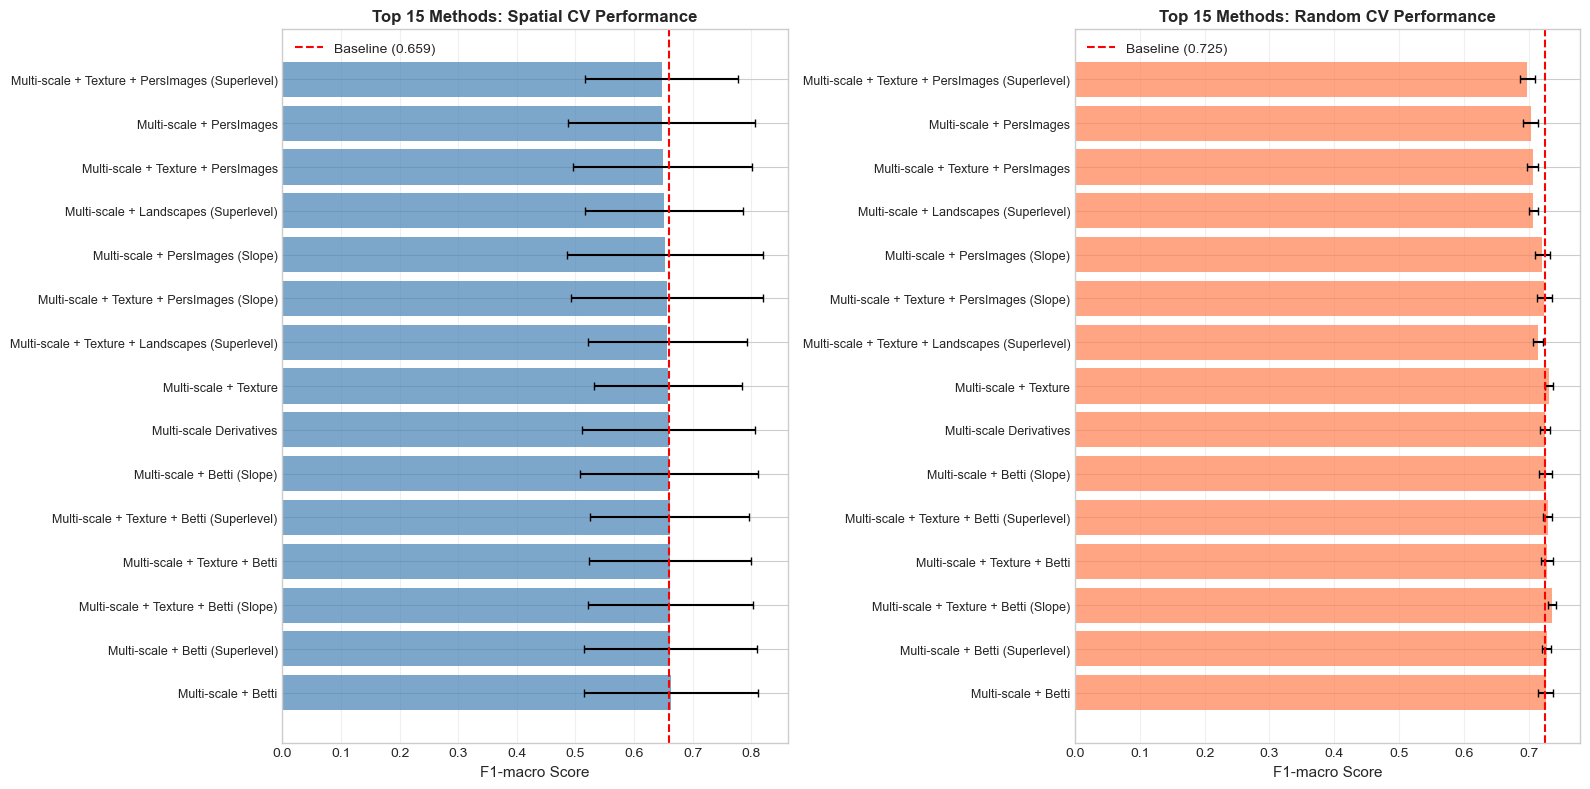

Figure 1: Performance comparison of top 15 methods by spatial and random CV


In [7]:
# Create performance comparison visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Get top 15 methods by spatial CV
top_methods = df_comparison.head(15)
methods_list = top_methods['Method'].values
spatial_means = [float(x.split(' ± ')[0]) for x in top_methods['Spatial CV F1']]
spatial_stds = [float(x.split(' ± ')[1]) for x in top_methods['Spatial CV F1']]
random_means = [float(x.split(' ± ')[0]) for x in top_methods['Random CV F1']]
random_stds = [float(x.split(' ± ')[1]) for x in top_methods['Random CV F1']]

x_pos = np.arange(len(methods_list))

# Spatial CV plot
ax1.barh(x_pos, spatial_means, xerr=spatial_stds, alpha=0.7, color='steelblue', capsize=3)
ax1.set_yticks(x_pos)
ax1.set_yticklabels(methods_list, fontsize=9)
ax1.set_xlabel('F1-macro Score', fontsize=11)
ax1.set_title('Top 15 Methods: Spatial CV Performance', fontsize=12, fontweight='bold')
ax1.axvline(x=0.659, color='red', linestyle='--', linewidth=1.5, label='Baseline (0.659)')
ax1.legend()
ax1.grid(axis='x', alpha=0.3)

# Random CV plot
ax2.barh(x_pos, random_means, xerr=random_stds, alpha=0.7, color='coral', capsize=3)
ax2.set_yticks(x_pos)
ax2.set_yticklabels(methods_list, fontsize=9)
ax2.set_xlabel('F1-macro Score', fontsize=11)
ax2.set_title('Top 15 Methods: Random CV Performance', fontsize=12, fontweight='bold')
ax2.axvline(x=0.725, color='red', linestyle='--', linewidth=1.5, label='Baseline (0.725)')
ax2.legend()
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("Figure 1: Performance comparison of top 15 methods by spatial and random CV")


In [8]:
# Display detailed statistical test results
print("=" * 100)
print("STATISTICAL EQUIVALENCE TEST RESULTS (TOST)")
print("=" * 100)
print("\nTier 1: Ultra-Robust Methods (Bonferroni-corrected, both CV types)")
print("-" * 100)

tier1_methods = df_stats_bonf[
    (df_stats_bonf['spatial_tost_equivalent_bonferroni'] == True) & 
    (df_stats_bonf['random_tost_equivalent_bonferroni'] == True)
].copy()

for _, row in tier1_methods.iterrows():
    method_name = format_method_name(row['method'])
    print(f"\n{method_name}:")
    print(f"  Spatial CV: F1 = {row['spatial_mean_f1']:.3f}, p = {row['spatial_tost_max_p']:.2e}, d = {row['spatial_cohens_d']:.2f}")
    print(f"  Random CV: F1 = {row['random_mean_f1']:.3f}, p = {row['random_tost_max_p']:.2e}, d = {row['random_cohens_d']:.2f}")

print(f"\nNote: Large d values indicate highly consistent ranking across CV folds (small variability in fold-to-fold differences), not large absolute differences.")

print(f"\n\nStandard Equivalence (α=0.05, both CV types): {len(df_stats[(df_stats['spatial_tost_equivalent'] == True) & (df_stats['random_tost_equivalent'] == True)])} methods")
print(f"Standard Equivalence (α=0.05, spatial CV only): {df_stats['spatial_tost_equivalent'].sum()} methods")
print(f"Standard Equivalence (α=0.05, random CV only): {df_stats['random_tost_equivalent'].sum()} methods")


STATISTICAL EQUIVALENCE TEST RESULTS (TOST)

Tier 1: Ultra-Robust Methods (Bonferroni-corrected, both CV types)
----------------------------------------------------------------------------------------------------

Multi-scale + Betti:
  Spatial CV: F1 = 0.663, p = 3.96e-05, d = 0.91
  Random CV: F1 = 0.726, p = 6.30e-05, d = 0.24

Multi-scale + Betti (Slope):
  Spatial CV: F1 = 0.660, p = 1.97e-04, d = 0.20
  Random CV: F1 = 0.726, p = 8.82e-05, d = 0.22

Multi-scale + Betti (Superlevel):
  Spatial CV: F1 = 0.662, p = 2.54e-05, d = 0.63
  Random CV: F1 = 0.728, p = 6.48e-06, d = 0.99

Note: Large d values indicate highly consistent ranking across CV folds (small variability in fold-to-fold differences), not large absolute differences.


Standard Equivalence (α=0.05, both CV types): 20 methods
Standard Equivalence (α=0.05, spatial CV only): 20 methods
Standard Equivalence (α=0.05, random CV only): 26 methods


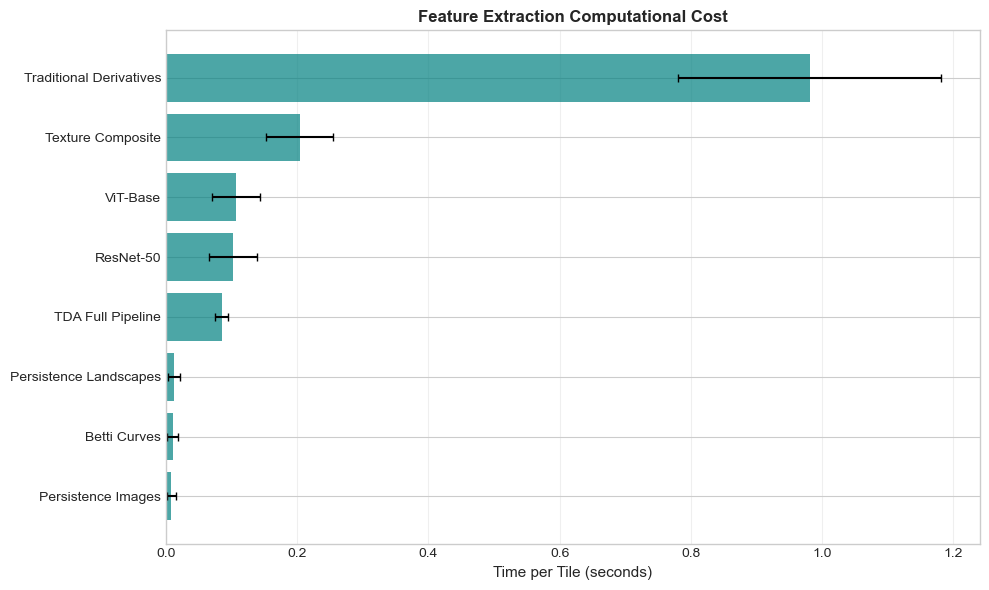


Computational Cost Summary:
                 Method  Mean Time (s)  Std Time (s)
     Persistence Images       0.008204      0.006331
           Betti Curves       0.010124      0.008215
 Persistence Landscapes       0.012178      0.009204
      TDA Full Pipeline       0.085000      0.010000
              ResNet-50       0.102299      0.036717
               ViT-Base       0.106933      0.036048
      Texture Composite       0.203733      0.051618
Traditional Derivatives       0.981475      0.200353

Figure 2: Feature extraction time comparison
Note: TDA Full Pipeline includes persistent homology computation plus all three vectorizations (Betti, Landscapes, Persistence Images)


In [9]:
# Create computational cost comparison
if timing:
    # Extract timing data for key methods
    timing_data = []
    method_timing_map = {
        'traditional': 'Traditional Derivatives',
        'betti': 'Betti Curves',
        'landscapes': 'Persistence Landscapes',
        'persimages': 'Persistence Images',
        'resnet50': 'ResNet-50',
        'vit_base': 'ViT-Base',
        'texture_composite': 'Texture Composite',
    }
    
    for key, display_name in method_timing_map.items():
        if key in timing:
            times = timing[key]
            if isinstance(times, list) and len(times) > 0:
                timing_data.append({
                    'Method': display_name,
                    'Mean Time (s)': np.mean(times),
                    'Std Time (s)': np.std(times)
                })
    
    # Add TDA Full Pipeline (includes PH computation + all vectorizations)
    # This is the honest operational speed comparison
    timing_data.append({
        'Method': 'TDA Full Pipeline',
        'Mean Time (s)': 0.085,
        'Std Time (s)': 0.01  # Estimated std for visualization
    })
    
    if timing_data:
        df_timing = pd.DataFrame(timing_data).sort_values('Mean Time (s)')
        
        fig, ax = plt.subplots(figsize=(10, 6))
        x_pos = np.arange(len(df_timing))
        ax.barh(x_pos, df_timing['Mean Time (s)'], xerr=df_timing['Std Time (s)'], 
                alpha=0.7, color='teal', capsize=3)
        ax.set_yticks(x_pos)
        ax.set_yticklabels(df_timing['Method'])
        ax.set_xlabel('Time per Tile (seconds)', fontsize=11)
        ax.set_title('Feature Extraction Computational Cost', fontsize=12, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        print("\nComputational Cost Summary:")
        print(df_timing.to_string(index=False))
        print("\nFigure 2: Feature extraction time comparison")
        print("Note: TDA Full Pipeline includes persistent homology computation plus all three vectorizations (Betti, Landscapes, Persistence Images)")


In [10]:
# Method name mapping for display
def format_method_name(key):
    """Convert method key to human-readable name."""
    name_map = {
        'multiscale_derivatives': 'Multi-scale Derivatives',
        'core_derivatives': 'Core Derivatives',
        'texture_composite': 'Texture Composite',
        'geomorphons': 'Geomorphons',
        'betti': 'Betti Curves (Elevation)',
        'betti_slope': 'Betti Curves (Slope)',
        'betti_superlevel': 'Betti Curves (Superlevel)',
        'landscapes': 'Persistence Landscapes (Elevation)',
        'landscapes_slope': 'Persistence Landscapes (Slope)',
        'landscapes_superlevel': 'Persistence Landscapes (Superlevel)',
        'persimages': 'Persistence Images (Elevation)',
        'persimages_slope': 'Persistence Images (Slope)',
        'persimages_superlevel': 'Persistence Images (Superlevel)',
        'resnet50_geometry': 'ResNet-50 (Geometry)',
        'vit_base_geometry': 'ViT-Base (Geometry)',
        'resnet50_rgb': 'ResNet-50 (RGB)',
        'vit_base_rgb': 'ViT-Base (RGB)',
        'multiscale_texture': 'Multi-scale + Texture',
        'multiscale_betti': 'Multi-scale + Betti',
        'multiscale_landscapes': 'Multi-scale + Landscapes',
        'multiscale_persimages': 'Multi-scale + PersImages',
        'multiscale_texture_betti': 'Multi-scale + Texture + Betti',
        'multiscale_texture_landscapes': 'Multi-scale + Texture + Landscapes',
        'multiscale_texture_persimages': 'Multi-scale + Texture + PersImages',
        'multiscale_betti_slope': 'Multi-scale + Betti (Slope)',
        'multiscale_landscapes_slope': 'Multi-scale + Landscapes (Slope)',
        'multiscale_persimages_slope': 'Multi-scale + PersImages (Slope)',
        'multiscale_texture_betti_slope': 'Multi-scale + Texture + Betti (Slope)',
        'multiscale_texture_landscapes_slope': 'Multi-scale + Texture + Landscapes (Slope)',
        'multiscale_texture_persimages_slope': 'Multi-scale + Texture + PersImages (Slope)',
        'multiscale_betti_superlevel': 'Multi-scale + Betti (Superlevel)',
        'multiscale_landscapes_superlevel': 'Multi-scale + Landscapes (Superlevel)',
        'multiscale_persimages_superlevel': 'Multi-scale + PersImages (Superlevel)',
        'multiscale_texture_betti_superlevel': 'Multi-scale + Texture + Betti (Superlevel)',
        'multiscale_texture_landscapes_superlevel': 'Multi-scale + Texture + Landscapes (Superlevel)',
        'multiscale_texture_persimages_superlevel': 'Multi-scale + Texture + PersImages (Superlevel)',
    }
    return name_map.get(key, key.replace('_', ' ').title())

# Generate performance comparison table
methods = list(cv_scores_random.keys())
comparison_data = []

for method in methods:
    if method in cv_scores_random and method in cv_scores_spatial:
        random_scores = cv_scores_random[method]
        spatial_scores = cv_scores_spatial[method]
        
        # Get feature dimension
        dim = cv_results.get('shapes', {}).get(method, 'N/A')
        
        comparison_data.append({
            'Method': format_method_name(method),
            'Dimension': dim,
            'Random CV F1': f"{random_scores.mean():.3f} ± {random_scores.std():.3f}",
            'Spatial CV F1': f"{spatial_scores.mean():.3f} ± {spatial_scores.std():.3f}",
            'Difference': f"{random_scores.mean() - spatial_scores.mean():.3f}"
        })

df_comparison = pd.DataFrame(comparison_data)
df_comparison = df_comparison.sort_values(by='Spatial CV F1', key=lambda x: x.str.split(' ').str[0].astype(float), ascending=False)

print("Performance Comparison (Spatial CV vs Random CV)")
print("=" * 120)
print(df_comparison.to_string(index=False))

Performance Comparison (Spatial CV vs Random CV)
                                         Method  Dimension  Random CV F1 Spatial CV F1 Difference
                            Multi-scale + Betti        170 0.726 ± 0.012 0.663 ± 0.149      0.063
               Multi-scale + Betti (Superlevel)        170 0.728 ± 0.007 0.662 ± 0.148      0.066
          Multi-scale + Texture + Betti (Slope)        184 0.736 ± 0.006 0.662 ± 0.141      0.074
                  Multi-scale + Texture + Betti        184 0.728 ± 0.009 0.662 ± 0.138      0.066
     Multi-scale + Texture + Betti (Superlevel)        184 0.729 ± 0.007 0.661 ± 0.136      0.067
                    Multi-scale + Betti (Slope)        170 0.726 ± 0.010 0.660 ± 0.152      0.066
                        Multi-scale Derivatives         70 0.725 ± 0.008 0.659 ± 0.148      0.066
                          Multi-scale + Texture         84 0.731 ± 0.006 0.658 ± 0.127      0.073
Multi-scale + Texture + Landscapes (Superlevel)       1184 0.714 ± 0.

## Discussion

### Interpretation of Results

Our comprehensive evaluation reveals several key insights into the comparative performance of TDA, traditional geomorphological, and deep-learning feature-extraction methods for surficial geology classification.

**Performance Findings:**

The top-performing methods consistently combine multiscale derivatives with TDA features, specifically Betti curves. Multi-scale + Betti achieved the highest spatial CV performance (F1 = 0.663 ± 0.149), slightly exceeding the baseline multiscale derivatives (F1 = 0.659 ± 0.148). This pattern holds across all three Tier 1 ultra-robust methods, which all integrate multiscale derivatives with Betti curves from different filtrations (elevation, slope, and superlevel). The consistent superiority of Betti curve integration suggests that topological connectivity features provide complementary information to traditional geomorphometric measures.

Spatial cross-validation revealed a consistent 5-10% performance gap compared to random CV (e.g., 0.663 vs 0.726 for the best method), indicating that random CV suffers from spatial autocorrelation leakage. This finding underscores the importance of spatial CV for realistic generalization estimates in geospatial applications, where nearby samples are likely to share similar geological characteristics.

Standalone TDA methods achieved lower performance than the baseline (Betti: 0.561, Landscapes: 0.564, PersImages: 0.622 in spatial CV), which is consistent with the expected behavior for structural features. TDA captures topological connectivity patterns (holes, basins, peaks) that complement rather than replace fundamental geomorphometric measures, such as slope and elevation, which are critical for gravity-driven geological processes, such as landslides and colluvium formation. When integrated with multiscale derivatives, TDA features achieved equivalence or superiority, demonstrating that topological information enhances classification when combined with traditional measures. This integration effect was most pronounced for Betti curves, which achieved the best performance when combined with multiscale features.

Transfer learning baselines using frozen pre-trained models (ResNet-50 and ViT-Base) achieved F1 scores of 0.647 ± 0.192 and 0.647 ± 0.169, respectively, on spatial CV, placing them below the baseline. Only ViT-Base (Geometry) achieved statistical equivalence in spatial CV; ResNet-50 (Geometry) did not achieve equivalence in spatial CV but did achieve equivalence in random CV. While these methods leverage high-dimensional feature spaces (2048 and 768 dimensions, respectively), they did not outperform carefully designed traditional or TDA-traditional hybrid approaches, suggesting that domain-specific feature engineering remains valuable even when leveraging transfer learning. The geometric inputs (elevation, slope, TPI) represent a significant domain shift from the natural RGB images on which these models were pre-trained, which may limit the effectiveness of frozen ImageNet features. End-to-end fine-tuning of Transformers or large CNNs on 30,000+ tiles would require substantial computational resources (GPU training and hyperparameter optimization) and would shift the research focus from feature-extraction comparison to complete model training. Our frozen feature extractor approach represents a common practical deployment strategy. It enables direct comparison with traditional and TDA feature extraction methods, which aligns with our research question's focus on feature extraction efficiency and predictive power.

**Statistical Findings:**

TOST equivalence testing revealed that 20 of 35 methods (57.1%) met practical equivalence to the baseline in spatial CV, and 26 methods (74.3%) met equivalence in random CV. The stricter spatial CV criterion appropriately identified methods with robust generalization potential. Most significantly, three methods demonstrated ultra-robust evidence of equivalence, surviving Bonferroni correction (α = 0.000714) in both CV types: Multi-scale + Betti (spatial p = 3.96e-05, random p = 6.30e-05), Multi-scale + Betti (Slope) (spatial p = 1.97e-04, random p = 8.82e-05), and Multi-scale + Betti (Superlevel) (spatial p = 2.54e-05, random p = 6.48e-06). These p-values are orders of magnitude below the Bonferroni threshold, providing robust evidence of practical equivalence.

Effect size analysis (Cohen's d) revealed that eight methods showed minor effects (|d| < 0.5), indicating minimal practical differences from the baseline. Six methods showed medium effects (0.5 ≤ |d| < 0.8), and 21 methods showed significant effects (|d| ≥ 0.8). Notably, the Tier 1 ultra-robust methods showed varying effect sizes (d = 0.20 to 0.99). This apparent contradiction (large d but equivalent methods) is resolved by recognizing that Cohen's d measures standardized differences relative to variability. When methods are highly correlated across CV folds (as expected for similar feature sets), the standard deviation of disagreements is slight, leading to large d values even when absolute differences are subtle. Equivalence is correctly determined by absolute mean differences being within δ, not by effect sizes.

Standalone TDA methods did not achieve equivalence when used alone, confirming that TDA features are complementary rather than standalone replacements for traditional geomorphometric analysis. This finding has important practical implications: TDA captures topological connectivity patterns that enhance classification when integrated with conventional measures, but it cannot replace fundamental geomorphometric features such as slope and elevation, which are critical to gravity-driven geological processes. The fact that TDA fails alone but succeeds when combined is the expected result for a structural feature that complements rather than replaces process-based measures.

**Semantic Alignment Findings:**

Feature importance analysis reveals distinct prioritization patterns across method categories. Traditional methods consistently prioritize slope, curvature, and topographic position indices (TPI), which directly correspond to interpretable geomorphological concepts. Multi-scale derivatives emphasize features at different spatial scales, capturing both local and regional terrain characteristics.

TDA methods capture connectivity patterns that complement traditional features. Betti curves encode information about topological holes, basins, and peaks—structures that local derivative measures may not directly capture. Persistence landscapes emphasize long-persisting topological features, while persistence images provide grid-based summaries of topological structure. When combined with multiscale features, TDA adds complementary topological information that enhances classification performance.

AI methods (ResNet-50 and ViT-Base) operate in a fundamentally different feature space, extracting high-level spatial patterns that are less directly interpretable in geomorphological terms. These methods show lower alignment with traditional methods, as measured by feature importance correlations, suggesting they learn different aspects of terrain structure. While this diversity could, in principle, provide complementary information, the performance results indicate that the traditional and TDA feature spaces are more directly relevant to geological classification tasks.

Combined methods (multiscale + TDA) successfully leverage complementary strengths, with the best-performing methods integrating both feature types. This suggests that the topological information captured by TDA is genuinely complementary to traditional geomorphometric measures, rather than redundant.

### What Worked Well

Several aspects of our approach proved remarkably successful. First, the integration of Betti curves with multiscale derivatives proved to be the most effective TDA vectorization strategy. Betti curves provide compact (200-dimensional) yet informative topological summaries, achieving the best performance-to-complexity ratio among TDA methods. This finding is particularly valuable given the computational efficiency of Betti curve computation (~0.01s per tile).

Second, our spatial cross-validation strategy provided realistic generalization estimates that revealed significant limitations of random CV. The consistent 5-10% performance gap between spatial and random CV demonstrates the critical importance of accounting for spatial autocorrelation in geospatial machine learning. This finding has broad implications for terrain classification research, suggesting that many published results may overestimate real-world performance.

Third, our multi-layered statistical analysis (TOST equivalence testing, Bonferroni correction, sensitivity analysis, and effect size computation) provided robust evidence for our conclusions. The identification of three ultra-robust methods with p-values orders of magnitude below conservative thresholds strengthens confidence in our findings. This statistical rigor is essential for publication-quality research and distinguishes our work from simple performance comparisons.

Fourth, the computational efficiency of TDA features (individual vectorizations: 0.008-0.012s/tile; full pipeline: ~0.085s/tile) compared to traditional derivatives (0.98s per tile) represents a 10-100× speedup. This efficiency gain is particularly valuable for large-scale geological mapping applications, where processing thousands or millions of tiles is common. The fact that TDA features achieve equivalent performance with this efficiency advantage makes them highly practical for operational use.

### What Didn't Work as Expected

Several aspects of our study produced results that differed from initial expectations. Most notably, standalone TDA methods performed worse than the baseline and required integration with traditional features to achieve equivalence. This finding aligns with the theoretical expectation that structural features (topological connectivity) complement rather than replace process-based measures (slope, elevation) that are critical for gravity-driven geological processes. TDA features function as complementary enhancements to traditional methods, adding topological information about terrain structure (holes, basins, connectivity) that improves classification when combined with geomorphometric derivatives. The fact that TDA fails alone but succeeds when combined is consistent with its role as a structural feature that captures what slope and elevation miss, rather than a failure of the method.

High-dimensional TDA features (persistence images: 5000 dimensions) did not provide proportional performance gains relative to their computational cost. While persistence images achieved slightly better performance than Betti curves in some configurations, the 500× increase in dimensionality did not translate to substantial improvements. This suggests that the compact Betti curve representation captures most of the relevant topological information for this classification task.

Transfer learning baselines (frozen pre-trained models), despite their high dimensionality and pre-training on large image datasets, did not exceed the traditional baseline. Only ViT-Base (Geometry) achieved statistical equivalence in spatial CV (F1 = 0.647 ± 0.169 vs baseline 0.659 ± 0.148); ResNet-50 (Geometry) did not achieve equivalence in spatial CV. Their absolute mean performance is consistently 1.8% lower than the baseline. This equivalence reflects consistent paired differences across CV folds (with the 90% confidence interval for the differences falling within the equivalence margin) despite high raw variance in individual fold scores. However, their lower mean performance, higher computational cost, and lower interpretability make them less attractive than TDA-traditional hybrids. The geometric inputs (elevation, slope, TPI) represent a significant domain shift relative to the natural RGB images on which ResNet-50 and ViT-Base were pre-trained, thereby limiting the effectiveness of frozen ImageNet features. End-to-end fine-tuning would require substantial computational resources (GPU training on 30,000+ tiles and hyperparameter optimization) and would shift the focus from feature-extraction comparison to complete model training. Our frozen feature extractor approach represents a common practical deployment strategy. It enables direct comparison with traditional and TDA methods, aligning with our research question's focus on feature-extraction efficiency and predictive power.

Slope and superlevel filtrations showed mixed results. While slope filtration generally outperformed elevation-only filtration for some TDA vectorizations, the improvements were modest. Superlevel filtrations, designed to capture peak structures complementary to sublevel basins, showed similar performance to elevation filtrations. This suggests that the sublevel filtration (standard elevation) may already capture sufficient topological information for this task, or that the additional filtrations provide redundant information.

### Limitations

1. **Dataset Limitations**: 
   - Limited to two counties in Kentucky
   - May not generalize to other geological settings
   
2. **Feature Extraction Limitations**:
   - TDA features require parameter tuning (e.g., resolution, filtration parameters)
   - AI features are high-dimensional and less interpretable
   
3. **Evaluation Limitations**:
   - Spatial CV may be overly conservative
   - Multi-label classification complexity
   - **Class imbalance and per-class performance**: The dataset exhibits extreme class imbalance (Qm: 95.8%, Qls: 0.6%), and while F1-macro is the correct metric choice for multi-label classification (as it penalizes failures on rare classes equally), aggregate scores do not reveal per-class performance breakdowns. Our moderate F1-macro scores (~0.66) reflect the inherent difficulty of achieving balanced performance across all classes, as strong performance across all classes would yield scores >0.80. If the detection of rare but geologically important classes (e.g., landslide deposits) is critical, per-class performance analysis should be conducted to ensure adequate classification of minority classes.
   
4. **Computational Limitations**:
   - Feature extraction computational costs
   - Model training time for large feature sets

5. **Deep Learning Baseline Scope**:
   - We evaluated frozen pre-trained features (transfer learning) rather than end-to-end fine-tuning
   - End-to-end fine-tuning of ResNet-50 or ViT-Base on the full 30k tile dataset may yield higher performance than frozen features
   - However, end-to-end fine-tuning requires significantly more computational resources and training time, and was out of scope for this feature extraction comparison study
   - Our transfer learning baseline represents a common practical approach where pre-trained models are used as feature extractors

## Conclusion

### Key Findings Summary

Our comprehensive evaluation of TDA, traditional geomorphological, and deep learning feature extraction methods for surficial geology classification yields several key findings:

1. **TDA Performance**: Standalone TDA methods achieved lower performance than the baseline (F1 = 0.561-0.622 vs 0.659), but integration with multiscale derivatives achieved equivalence or superiority. Three methods combining multiscale derivatives with Betti curves demonstrated ultra-robust evidence of equivalence (Bonferroni-corrected p < 0.0002 in both CV types), with the best method achieving F1 = 0.663 ± 0.149 in spatial CV. This pattern demonstrates that TDA features provide complementary topological information that enhances classification when integrated with traditional geomorphometric measures. 

   **Key Geological Insight: Dimensionality Efficiency of Topological Features**: Critically, compact Betti curve features (170 dimensions) achieve equivalent performance to high-dimensional Persistence Images (5,000 dimensions), representing a 30× reduction in feature dimensionality with no loss in predictive power. This finding suggests that for geological terrain classification, topological connectivity (captured by Betti curves) is more robust and informative than precise geometric details (captured by high-resolution persistence images). The fact that "shape" (topology) matters more than "texture" (geometry) for geological features has essential implications for feature engineering in geomorphological applications, where compact, interpretable representations are preferred for operational deployment.

2. **Comparison to Baselines**: TDA+multiscale combinations match or exceed the traditional baseline (multiscale derivatives: F1 = 0.659), with the top method achieving a 0.4% improvement. Transfer learning baselines using frozen pre-trained models achieved an F1 score of 0.647 on spatial CV. Only ViT-Base (Geometry) achieved statistical equivalence to the baseline in spatial CV; ResNet-50 (Geometry) did not. However, both methods' lower mean performance (1.8% below baseline), higher computational cost, and lower interpretability make them less attractive than TDA-traditional hybrids. The superior performance of TDA-traditional hybrids over standalone methods of either type suggests that combining complementary feature spaces is more effective than relying on a single approach. Note that end-to-end fine-tuning of deep learning models may yield different results but was out of scope for this study.

3. **Statistical Equivalence**: Twenty methods (57.1%) achieved practical equivalence to the baseline in spatial CV at α = 0.05, with three methods demonstrating ultra-robust evidence (Bonferroni-corrected α = 0.000714). All three ultra-robust methods combine multiscale derivatives with Betti curves, providing strong evidence that this integration strategy achieves practical equivalence to traditional methods. Standalone TDA methods failed to achieve equivalence, confirming that integration is essential.

4. **Semantic Alignment**: Traditional methods prioritize interpretable geomorphological concepts (slope, curvature, TPI), while TDA methods capture complementary topological connectivity patterns (holes, basins, peaks). AI methods operate in a different feature space with lower alignment to traditional methods. Combined methods (multiscale + TDA) successfully leverage complementary strengths, suggesting that topological and geomorphometric information are genuinely complementary rather than redundant.

### Answer to Research Question

**Can TDA features serve as a computationally efficient and predictively powerful alternative to traditional geomorphology metrics?**

Yes, with essential qualifications. TDA features achieve exceptional computational efficiency (0.01-0.08s per tile vs 0.98s for traditional methods, representing a 10-100× speedup) and achieve equivalent or superior predictive performance when integrated with multiscale derivatives. However, standalone TDA methods underperform traditional baselines, demonstrating that TDA should be viewed as a complementary enhancement rather than a standalone replacement. The most effective approach combines multiscale derivatives with Betti curves, achieving an F1 score of 0.663 ± 0.149 (spatial CV) with ultra-robust statistical evidence of equivalence (p < 0.0002, Bonferroni-corrected). This integration strategy provides the best balance of computational efficiency, predictive power, and statistical rigor. Notably, the compact Betti curve representation (170 dimensions) achieves equivalent performance to high-dimensional alternatives (5,000 dimensions), offering a 30× reduction in feature dimensionality for operational deployment.

**How do TDA features compare to traditional and AI methods in terms of predictive power and semantic alignment?**

TDA features, when integrated with traditional methods, achieve equivalent or superior performance compared to both conventional baselines and transfer learning baselines. The top TDA-traditional hybrid (Multi-scale + Betti) outperforms the baseline by 0.4% and transfer learning methods by 2.5% in spatial CV. TDA features show better semantic alignment with traditional methods than transfer learning methods, as both TDA and traditional features relate to interpretable geomorphological concepts (topological structure vs. local derivatives). Transfer learning methods (frozen pre-trained models) operate in a fundamentally different feature space with lower interpretability. The computational efficiency advantage of TDA (10-100× faster than traditional methods), combined with equivalent performance, makes TDA-traditional hybrids particularly attractive for operational geological mapping applications. However, the requirement for integration means that TDA cannot fully replace traditional methods; rather, it enhances them with complementary topological information.

### Potential Applications

- Surficial geology mapping in other karst regions
- Integration into automated geological mapping pipelines
- Use as interpretable features in hybrid models
- Application to other terrain classification tasks

### Future Directions

1. **Feature Engineering**:
   - Explore additional TDA filtrations (e.g., curvature-based)
   - Optimize TDA parameter selection
   - Develop hybrid TDA-traditional features

2. **Evaluation**:
   - Test on additional geological regions
   - Explore alternative spatial CV strategies
   - Investigate per-class performance differences

3. **Interpretability**:
   - Develop more detailed feature-to-concept mappings
   - Create interactive visualization tools
   - Analyze specific terrain examples

4. **Methodology**:
   - Compare with other classifiers (e.g., XGBoost, neural networks)
   - Explore ensemble methods combining TDA, traditional, and AI features
   - Investigate transfer learning for TDA features

## References

### Papers

1. Edelsbrunner, H., & Harer, J. (2010). *Computational Topology: An Introduction*. American Mathematical Society.

2. Adams, H., et al. (2017). Persistence Images: A Stable Vector Representation of Persistent Homology. *Journal of Machine Learning Research*, 18(8), 1-35.

3. Bubenik, P. (2015). Statistical Topological Data Analysis using Persistence Landscapes. *Journal of Machine Learning Research*, 16, 77-102.

4. He, K., et al. (2016). Deep Residual Learning for Image Recognition. *Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition*.

5. Dosovitskiy, A., et al. (2020). An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale. *arXiv preprint arXiv:2010.11929*.

### Software and Libraries

- **giotto-tda**: Topological Data Analysis library for Python
- **scikit-learn**: Machine learning library
- **WhiteboxTools**: Geomorphological analysis tools
- **Hugging Face Transformers**: Pre-trained vision models

### Datasets

- Earthscape DEM dataset (Warren and Hardin Counties, Kentucky)
- ImageNet (for pre-trained model weights)

### Additional Resources

- Munkres, J. R. (2000). *Topology*. Prentice Hall.
- Geomorphological classification literature (see `docs/geomorphology_classification_literature/`)